In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# == CHUẨN HÓA GIAO DIỆN ==
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'figure.dpi':       120,
    'figure.titlesize': 14,
    'axes.titlesize':   11,
    'axes.labelsize':   10,
    'xtick.labelsize':  9,
    'ytick.labelsize':  9,
})
PALETTE_CAT = 'viridis'
COLOR_MAIN  = '#3B82F6'
COLOR_ACC   = '#F59E0B'
COLOR_TEAL  = '#0F766E'

# == ĐỌC VÀ CHUẨN BỊ DỮ LIỆU ==
file_path = '/kaggle/input/datasets/phn217/ds108-cleaned/ds108_cleaned.csv'
try:
    df = pd.read_csv(file_path, encoding='utf-8-sig')
except FileNotFoundError:
    print("Vui lòng kiểm tra lại đường dẫn file.")

# Chỉ phân tích dòng có stats hợp lệ
valid = df[df['view_count'] > 0].copy()

# Tạo các cột log và rate
valid['log_view_count'] = np.log1p(valid['view_count'])
if 'like_rate' not in valid.columns:
    valid['like_rate'] = valid['likes'] / valid['view_count']
if 'comment_rate' not in valid.columns:
    valid['comment_rate'] = valid['comments'] / valid['view_count']

# Tạo bucket
valid['duration_bucket'] = pd.cut(
    valid['duration_seconds'],
    bins=[0, 60, 300, 600, 1200, 3600, 99999],
    labels=['<1 phút', '1-5 phút', '5-10 phút', '10-20 phút', '20-60 phút', '>60 phút']
)
valid['channel_age_bucket'] = pd.cut(
    valid['channel_age_days'],
    bins=[0, 365, 1095, 2555, 5475, 99999],
    labels=['<1 năm', '1-3 năm', '3-7 năm', '7-15 năm', '>15 năm']
)

# Thứ tự sắp xếp
CAT_ORDER_ENG = (valid.groupby('category_name')['engagement_rate']
                 .median().sort_values(ascending=False).index.tolist())
CAT_ORDER_VIEW = (valid.groupby('category_name')['view_count']
                  .median().sort_values(ascending=False).index.tolist())
REGION_ORDER = (valid.groupby('region')['view_count']
                .median().sort_values(ascending=False).index.tolist())

print("Chuẩn bị dữ liệu hoàn tất!")

Chuẩn bị dữ liệu hoàn tất!


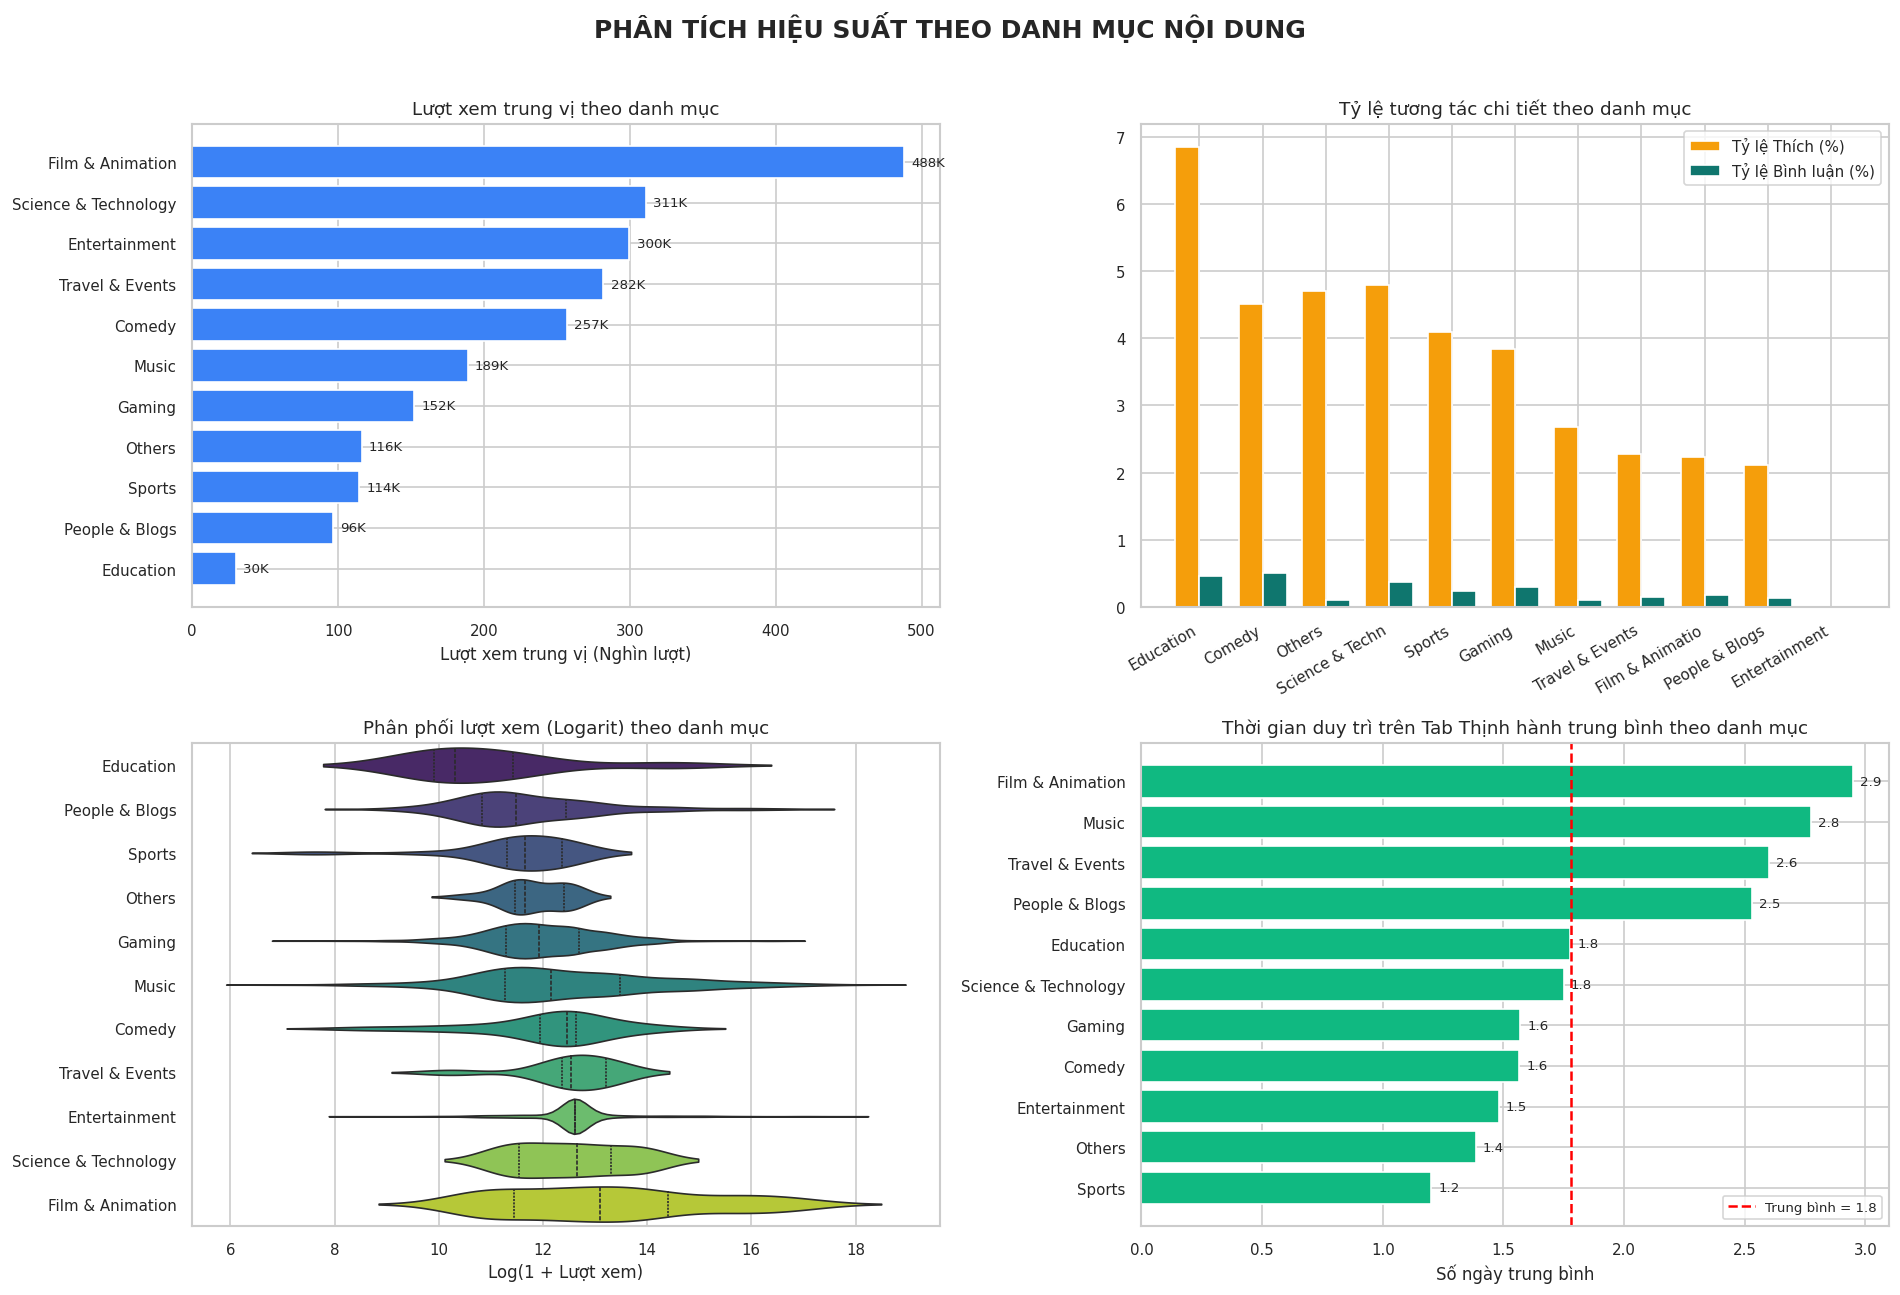

In [2]:
# == BIỂU ĐỒ 1: HIỆU SUẤT THEO CATEGORY ==
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('PHÂN TÍCH HIỆU SUẤT THEO DANH MỤC NỘI DUNG', fontsize=15, fontweight='bold', y=0.98)

# 1A: Median view_count
cat_view = valid.groupby('category_name')['view_count'].median().sort_values(ascending=True).reset_index()
axes[0,0].barh(cat_view['category_name'], cat_view['view_count'] / 1e3, color=COLOR_MAIN, edgecolor='white')
for i, (_, row) in enumerate(cat_view.iterrows()):
    axes[0,0].text(row['view_count']/1e3 + 5, i, f"{row['view_count']/1e3:.0f}K", va='center', fontsize=8)
axes[0,0].set_title('Lượt xem trung vị theo danh mục')
axes[0,0].set_xlabel('Lượt xem trung vị (Nghìn lượt)')

# 1B: Grouped Bar - Like Rate & Comment Rate
eng_by_cat = valid.groupby("category_name")[["like_rate", "comment_rate"]].median().reindex(CAT_ORDER_ENG) * 100
x_pos = np.arange(len(eng_by_cat))
w = 0.38
axes[0,1].bar(x_pos - w/2, eng_by_cat["like_rate"], width=w, label="Tỷ lệ Thích (%)", color=COLOR_ACC)
axes[0,1].bar(x_pos + w/2, eng_by_cat["comment_rate"], width=w, label="Tỷ lệ Bình luận (%)", color=COLOR_TEAL)
axes[0,1].set_xticks(x_pos)
axes[0,1].set_xticklabels([c[:15] for c in eng_by_cat.index], rotation=30, ha="right")
axes[0,1].set_title('Tỷ lệ tương tác chi tiết theo danh mục')
axes[0,1].legend(fontsize=9)

# 1C: Violin Plot - Phân phối log(View)
sns.violinplot(data=valid, x='log_view_count', y='category_name', order=list(reversed(CAT_ORDER_VIEW)), 
               palette=PALETTE_CAT, inner='quartile', linewidth=1, ax=axes[1,0])
axes[1,0].set_title('Phân phối lượt xem (Logarit) theo danh mục')
axes[1,0].set_xlabel('Log(1 + Lượt xem)')
axes[1,0].set_ylabel('')

# 1D: Số ngày trending trung bình
cat_trend = df.groupby('category_name')['days_trending'].mean().sort_values(ascending=True).reset_index()
axes[1,1].barh(cat_trend['category_name'], cat_trend['days_trending'], color='#10B981', edgecolor='white')
for i, (_, row) in enumerate(cat_trend.iterrows()):
    axes[1,1].text(row['days_trending'] + 0.03, i, f"{row['days_trending']:.1f}", va='center', fontsize=8)
axes[1,1].axvline(df['days_trending'].mean(), color='red', ls='--', lw=1.5, label=f"Trung bình = {df['days_trending'].mean():.1f}")
axes[1,1].set_title('Thời gian duy trì trên Tab Thịnh hành trung bình theo danh mục')
axes[1,1].set_xlabel('Số ngày trung bình')
axes[1,1].legend(fontsize=8)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

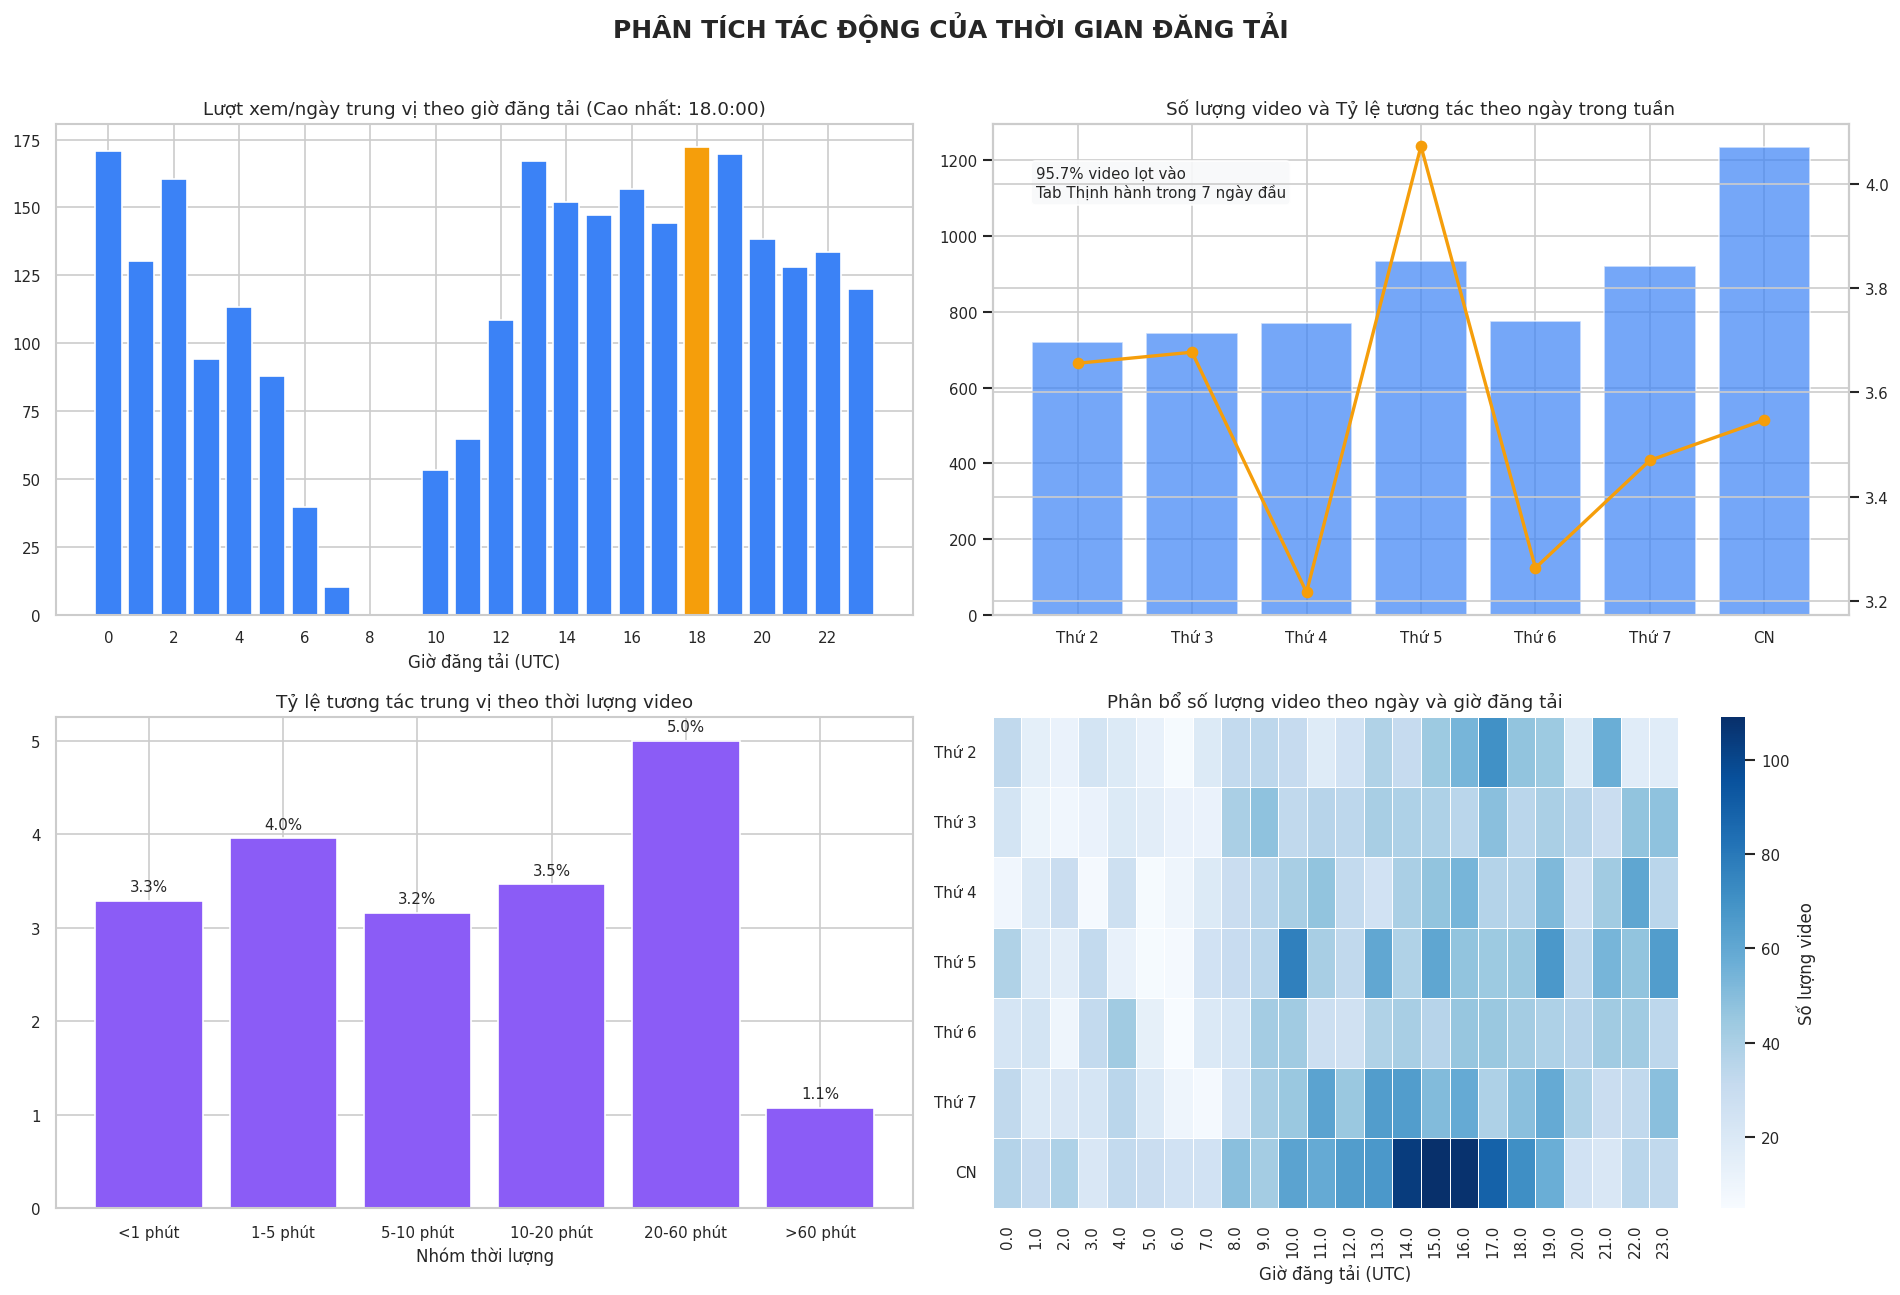

In [3]:
# == BIỂU ĐỒ 2: THỜI GIAN & LỊCH ĐĂNG ==
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('PHÂN TÍCH TÁC ĐỘNG CỦA THỜI GIAN ĐĂNG TẢI', fontsize=15, fontweight='bold', y=0.98)

# 2A: Median views_per_day theo publish_hour
hour_perf = valid.groupby('publish_hour')['views_per_day'].median().reset_index()
peak_hour = hour_perf.loc[hour_perf['views_per_day'].idxmax(), 'publish_hour']
bar_colors = [COLOR_ACC if h == peak_hour else COLOR_MAIN for h in hour_perf['publish_hour']]
axes[0,0].bar(hour_perf['publish_hour'], hour_perf['views_per_day'] / 1e3, color=bar_colors, edgecolor='white')
axes[0,0].set_title(f'Lượt xem/ngày trung vị theo giờ đăng tải (Cao nhất: {peak_hour}:00)')
axes[0,0].set_xlabel('Giờ đăng tải (UTC)')
axes[0,0].set_xticks(range(0, 24, 2))

# 2B: Tốc độ Trending
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_vi    = ['Thứ 2', 'Thứ 3', 'Thứ 4', 'Thứ 5', 'Thứ 6', 'Thứ 7', 'CN']
day_count = df['publish_day_of_week'].value_counts().reindex(day_order)
day_eng   = valid.groupby('publish_day_of_week')['engagement_rate'].median().reindex(day_order) * 100

ax_day = axes[0,1]
ax_day2 = ax_day.twinx()
ax_day.bar(day_vi, day_count.values, color=COLOR_MAIN, alpha=0.7, label='Số lượng video')
ax_day2.plot(day_vi, day_eng.values, color=COLOR_ACC, marker='o', lw=2, label='Tỷ lệ Tương tác (%)')
ax_day.set_title('Số lượng video và Tỷ lệ tương tác theo ngày trong tuần')
pct_week = (df["days_since_publish"] <= 7).mean() * 100
ax_day.text(0.05, 0.85, f"{pct_week:.1f}% video lọt vào\nTab Thịnh hành trong 7 ngày đầu", 
            transform=ax_day.transAxes, fontsize=9, bbox=dict(boxstyle="round", fc="#f8f9fa", alpha=0.9))

# 2C: Median engagement_rate theo duration_bucket
dur_perf = valid.groupby('duration_bucket', observed=True)['engagement_rate'].median().reset_index()
axes[1,0].bar(dur_perf['duration_bucket'].astype(str), dur_perf['engagement_rate'] * 100, color='#8B5CF6')
for i, row in dur_perf.iterrows():
    axes[1,0].text(i, row['engagement_rate']*100 + 0.1, f"{row['engagement_rate']*100:.1f}%", ha='center', fontsize=9)
axes[1,0].set_title('Tỷ lệ tương tác trung vị theo thời lượng video')
axes[1,0].set_xlabel('Nhóm thời lượng')

# 2D: Heatmap Giờ x Ngày
pivot_heat = (valid.groupby(["publish_day_of_week", "publish_hour"]).size().reset_index(name="count")
              .pivot(index="publish_day_of_week", columns="publish_hour", values="count")
              .reindex(day_order).fillna(0))
sns.heatmap(pivot_heat, ax=axes[1,1], cmap="Blues", linewidths=0.3, cbar_kws={"label": "Số lượng video"}, fmt=".0f")
axes[1,1].set_title('Phân bổ số lượng video theo ngày và giờ đăng tải')
axes[1,1].set_xlabel('Giờ đăng tải (UTC)')
axes[1,1].set_yticklabels(day_vi, rotation=0)
axes[1,1].set_ylabel('')

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

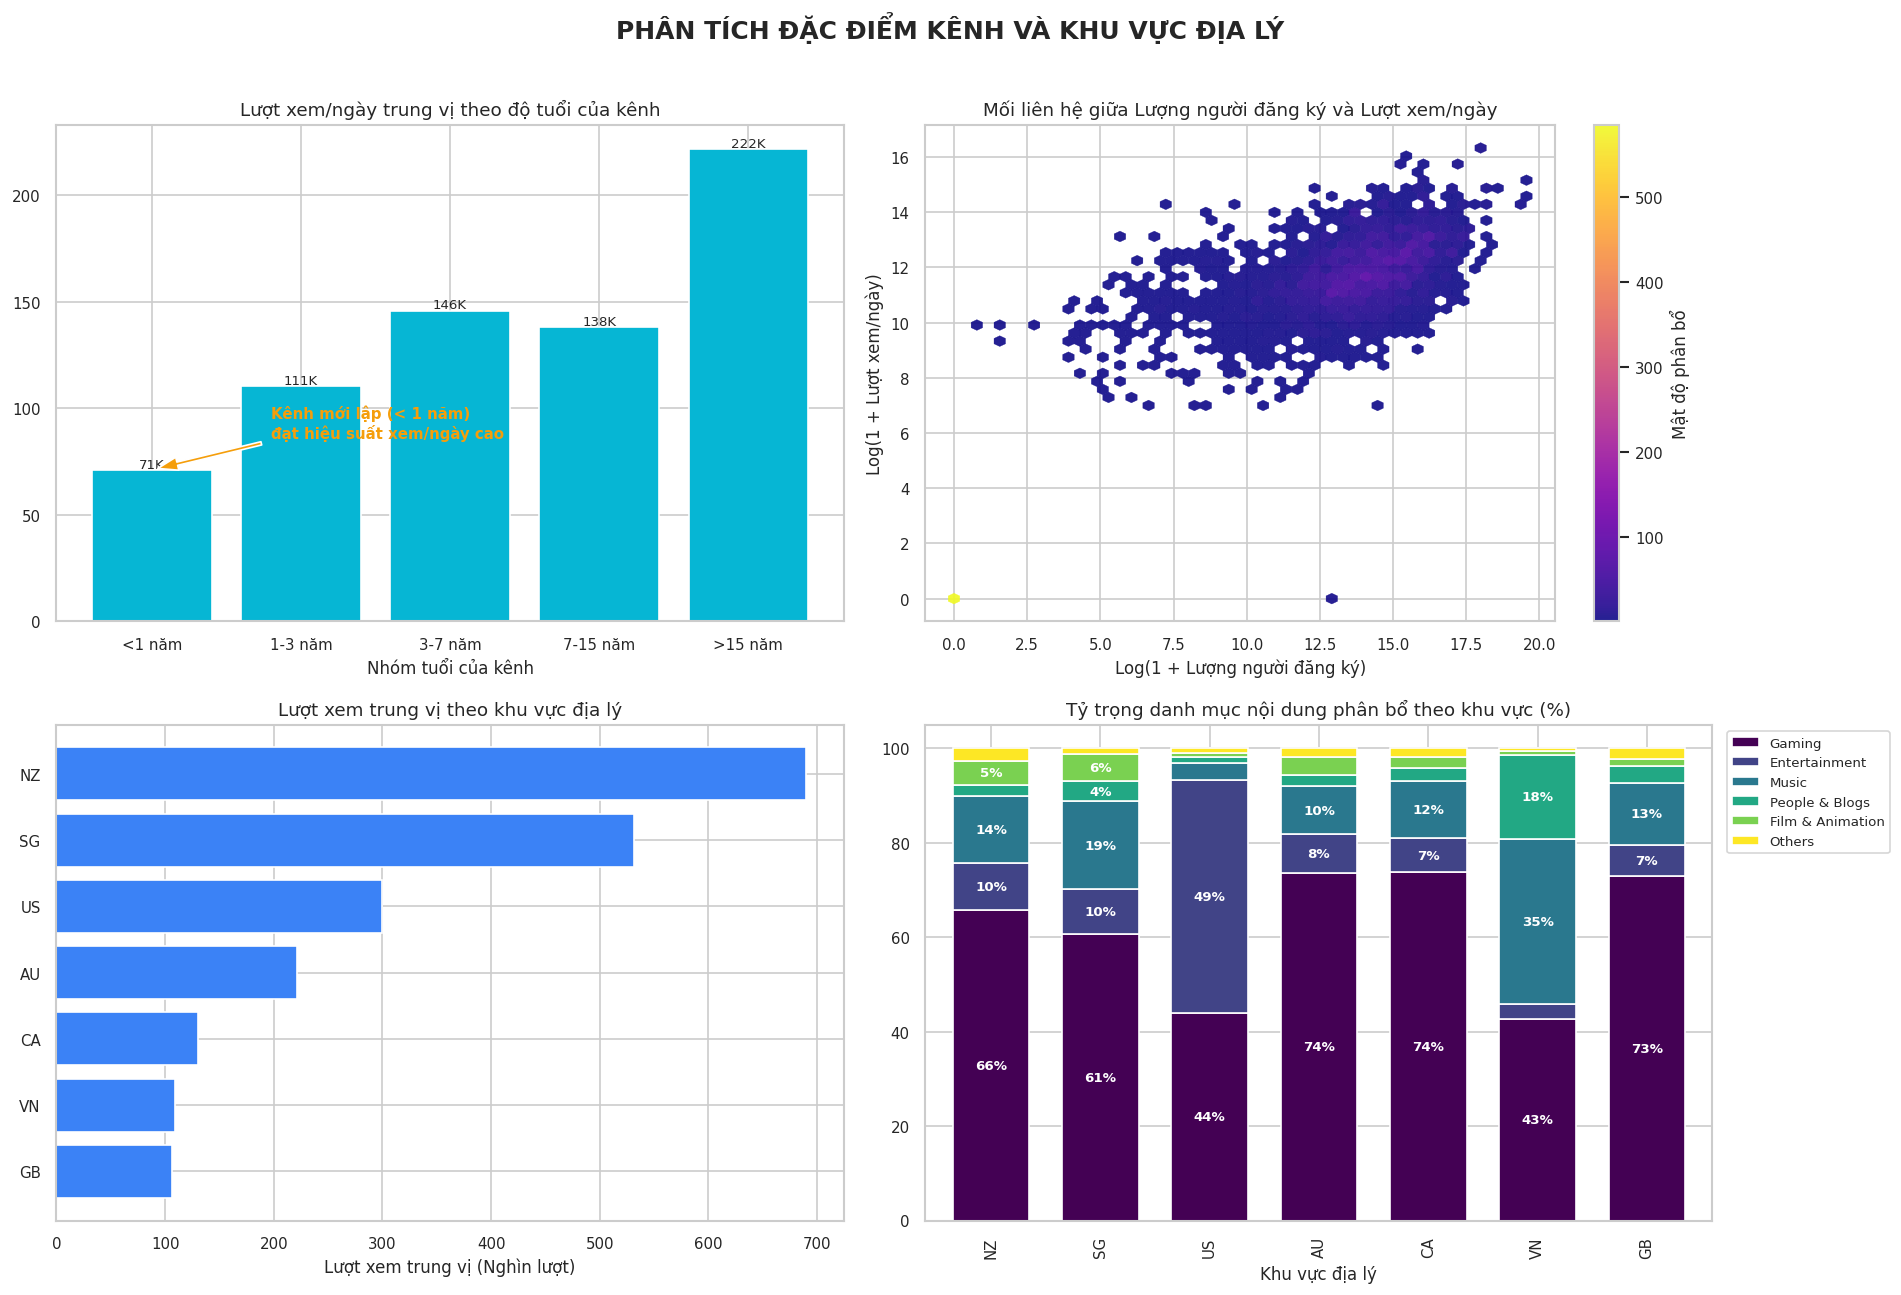

In [4]:
# == BIỂU ĐỒ 3: ĐẶC ĐIỂM KÊNH & KHU VỰC ==
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('PHÂN TÍCH ĐẶC ĐIỂM KÊNH VÀ KHU VỰC ĐỊA LÝ', fontsize=15, fontweight='bold', y=0.98)

# 3A: Median views theo age bucket
age_perf = valid.groupby('channel_age_bucket', observed=True).agg(median_views=('views_per_day','median'), count=('views_per_day','count')).reset_index()
axes[0,0].bar(age_perf['channel_age_bucket'].astype(str), age_perf['median_views'] / 1e3, color='#06B6D4')
for i, row in age_perf.iterrows():
    axes[0,0].text(i, row['median_views']/1e3 + 1, f"{row['median_views']/1e3:.0f}K", ha='center', fontsize=8)
axes[0,0].set_title('Lượt xem/ngày trung vị theo độ tuổi của kênh')
axes[0,0].set_xlabel('Nhóm tuổi của kênh')

if len(age_perf) > 0:
    axes[0,0].annotate("Kênh mới lập (< 1 năm)\nđạt hiệu suất xem/ngày cao", 
                       xy=(0, age_perf['median_views'].iloc[0] / 1e3), 
                       xytext=(0.8, (age_perf['median_views'].iloc[0] / 1e3) + 15),
                       arrowprops=dict(facecolor=COLOR_ACC, shrink=0.05, width=2, headwidth=8),
                       fontsize=9, color=COLOR_ACC, fontweight='bold')

# 3B: Hexbin Chống Overplotting
x_sub = np.log1p(valid['channel_subscriber_count'])
y_view = np.log1p(valid['views_per_day'])
hb = axes[0,1].hexbin(x_sub, y_view, gridsize=50, cmap='plasma', mincnt=1, linewidths=0.2, alpha=0.9)
fig.colorbar(hb, ax=axes[0,1], label='Mật độ phân bổ')
axes[0,1].set_title('Mối liên hệ giữa Lượng người đăng ký và Lượt xem/ngày')
axes[0,1].set_xlabel('Log(1 + Lượng người đăng ký)')
axes[0,1].set_ylabel('Log(1 + Lượt xem/ngày)')

# 3C: Median view_count theo region
reg_view = valid.groupby('region')['view_count'].median().sort_values(ascending=True).reset_index()
axes[1,0].barh(reg_view['region'], reg_view['view_count'] / 1e3, color=COLOR_MAIN)
axes[1,0].set_title('Lượt xem trung vị theo khu vực địa lý')
axes[1,0].set_xlabel('Lượt xem trung vị (Nghìn lượt)')

# 3D: Stacked bar
cat_region = df.groupby(['region','category_name']).size().unstack(fill_value=0)
cat_region_pct = cat_region.div(cat_region.sum(axis=1), axis=0) * 100
top_cats = ['Gaming','Entertainment','Music','People & Blogs','Film & Animation']
plot_df = cat_region_pct[top_cats].copy()
plot_df['Others'] = cat_region_pct.drop(columns=top_cats, errors='ignore').sum(axis=1)
plot_df.reindex(REGION_ORDER).plot(kind='bar', stacked=True, ax=axes[1,1], colormap=PALETTE_CAT, width=0.7)

for c in axes[1,1].containers:
    # Chỉ hiển thị số % nếu chiếm hơn 4% để tránh chữ bị đè lên nhau ở các phân khúc quá nhỏ
    labels = [f'{v.get_height():.0f}%' if v.get_height() > 4 else '' for v in c]
    axes[1,1].bar_label(c, labels=labels, label_type='center', fontsize=8, color='white', fontweight='bold')

axes[1,1].set_title('Tỷ trọng danh mục nội dung phân bổ theo khu vực (%)')
axes[1,1].set_xlabel('Khu vực địa lý')
axes[1,1].legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

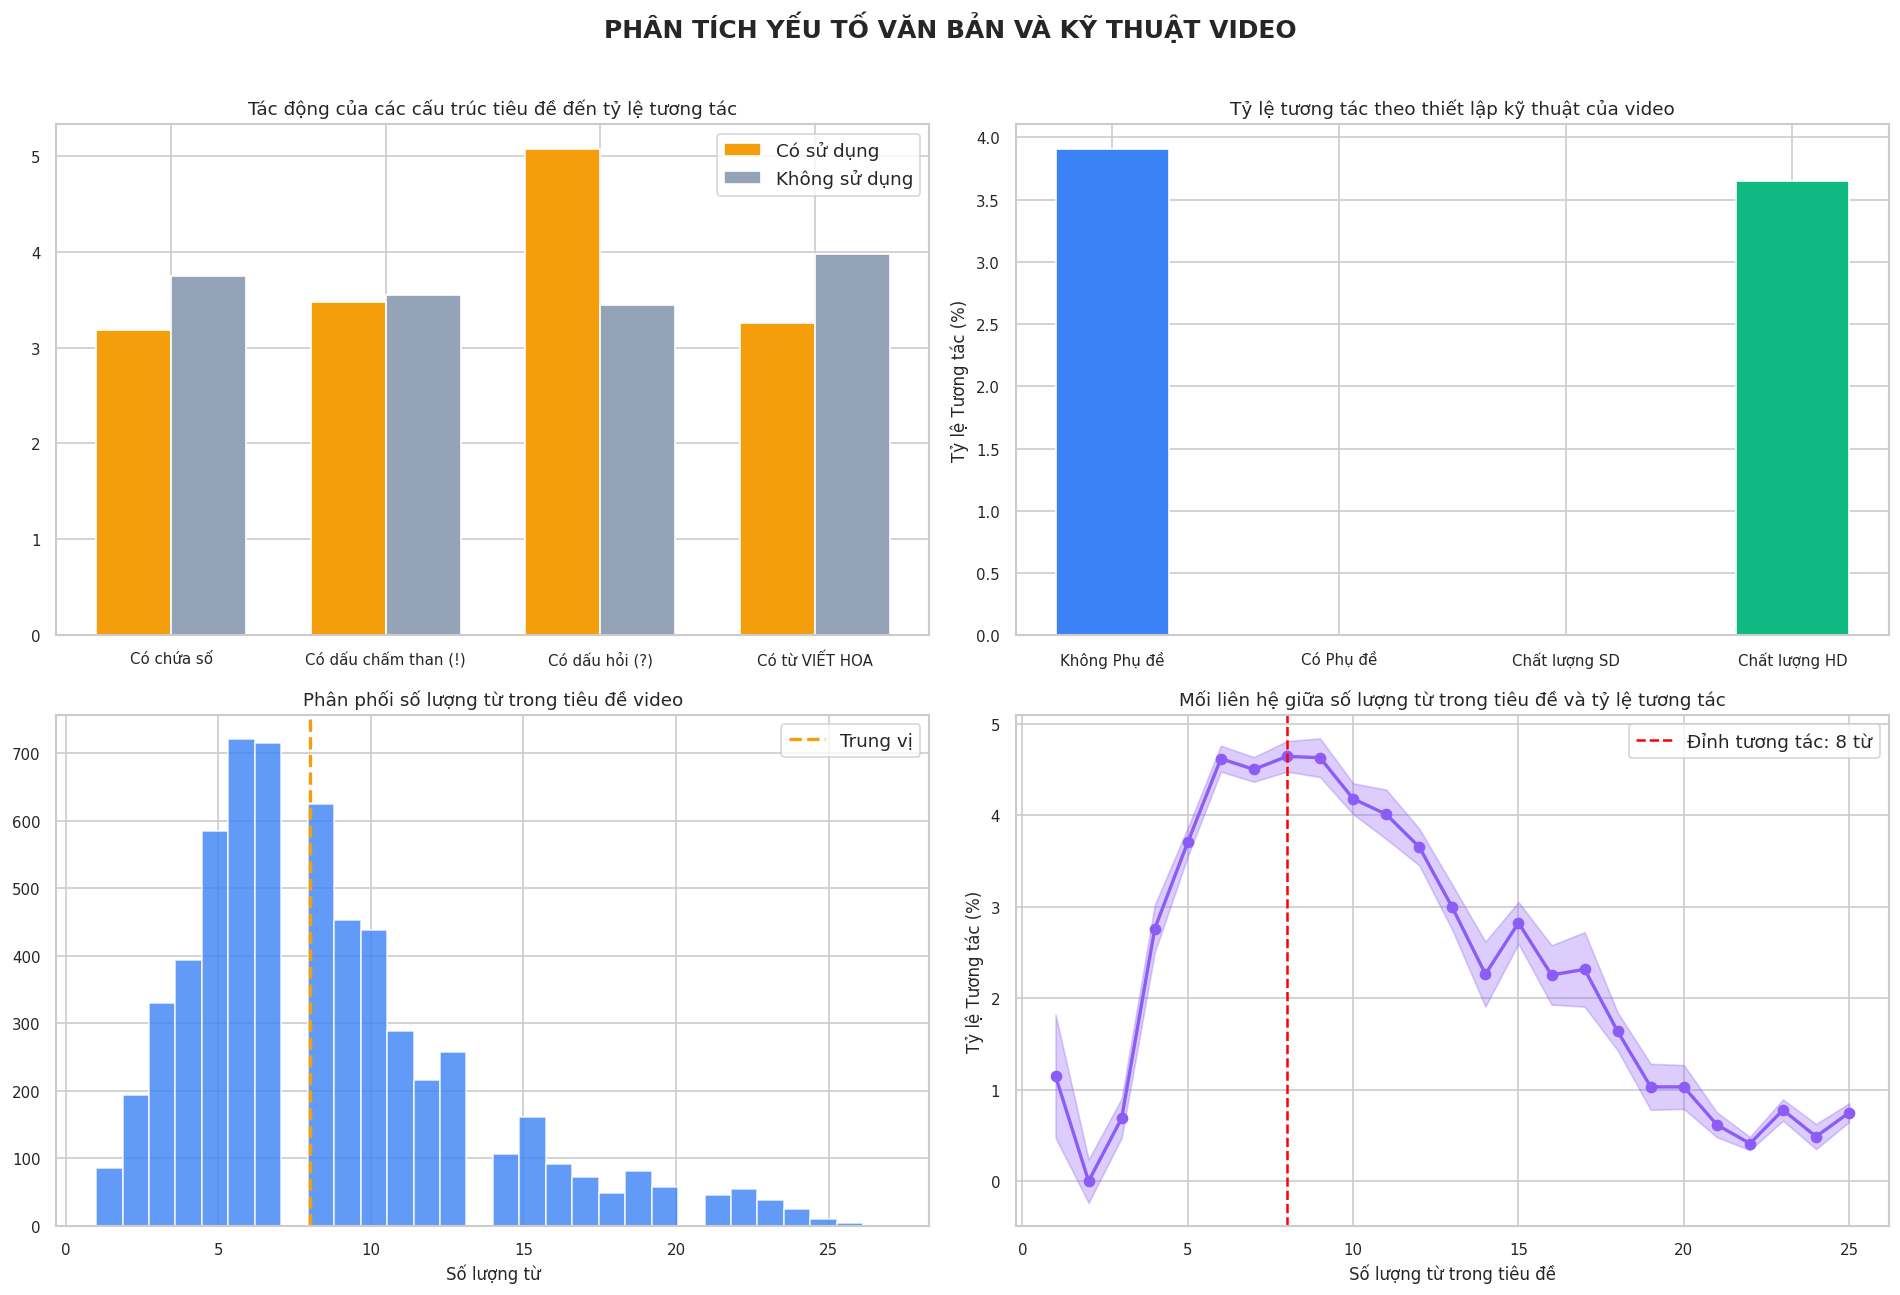

In [5]:
# == BIỂU ĐỒ 4: ĐẶC ĐIỂM TIÊU ĐỀ & KỸ THUẬT ==
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('PHÂN TÍCH YẾU TỐ VĂN BẢN VÀ KỸ THUẬT VIDEO', fontsize=15, fontweight='bold', y=0.98)

# 4A: Tác động tính năng title
bool_features = {
    'title_has_number': 'Có chứa số',
    'title_has_question': 'Có dấu hỏi (?)',
    'title_has_exclamation': 'Có dấu chấm than (!)',
    'title_all_caps_word': 'Có từ VIẾT HOA',
}
res = []
for col, label in bool_features.items():
    if col in valid.columns:
        for val, grp in [(True, "Có sử dụng"), (False, "Không sử dụng")]:
            med = valid.loc[valid[col] == val, "engagement_rate"].median() * 100
            res.append({"feature": label, "group": grp, "median": med})
if res:
    df_res = pd.DataFrame(res).pivot(index="feature", columns="group", values="median")
    x_pos2 = np.arange(len(df_res))
    w2 = 0.35
    axes[0,0].bar(x_pos2 - w2/2, df_res["Có sử dụng"], width=w2, label='Có sử dụng', color=COLOR_ACC)
    axes[0,0].bar(x_pos2 + w2/2, df_res["Không sử dụng"], width=w2, label='Không sử dụng', color='#94A3B8')
    axes[0,0].set_xticks(x_pos2)
    axes[0,0].set_xticklabels(df_res.index)
    axes[0,0].set_title('Tác động của các cấu trúc tiêu đề đến tỷ lệ tương tác')
    axes[0,0].legend()

# 4B: Median engagement
comp_data = {
    'Không Phụ đề': valid[valid['has_captions']==False]['engagement_rate'].median()*100,
    'Có Phụ đề': valid[valid['has_captions']==True]['engagement_rate'].median()*100,
    'Chất lượng SD': valid[valid['definition']=='sd']['engagement_rate'].median()*100,
    'Chất lượng HD': valid[valid['definition']=='hd']['engagement_rate'].median()*100,
}
axes[0,1].bar(list(comp_data.keys()), list(comp_data.values()), color=[COLOR_MAIN, COLOR_ACC, '#94A3B8', '#10B981'], width=0.5)
axes[0,1].set_title('Tỷ lệ tương tác theo thiết lập kỹ thuật của video')
axes[0,1].set_ylabel('Tỷ lệ Tương tác (%)')

# 4C: Phân phối số từ
axes[1,0].hist(valid['title_word_count'], bins=30, color=COLOR_MAIN, edgecolor='white', alpha=0.8)
axes[1,0].axvline(valid['title_word_count'].median(), color=COLOR_ACC, ls='--', lw=2, label="Trung vị")
axes[1,0].set_title('Phân phối số lượng từ trong tiêu đề video')
axes[1,0].set_xlabel('Số lượng từ')
axes[1,0].legend()

# 4D: Mối liên hệ Số từ và Engagement
wc_grouped = valid[valid['title_word_count'] <= 25].groupby('title_word_count')['engagement_rate'].agg(['median', 'sem']).reset_index()
axes[1,1].fill_between(wc_grouped['title_word_count'], 
                       (wc_grouped['median'] - wc_grouped['sem'])*100, 
                       (wc_grouped['median'] + wc_grouped['sem'])*100, color='#8B5CF6', alpha=0.3)
axes[1,1].plot(wc_grouped['title_word_count'], wc_grouped['median']*100, 'o-', color='#8B5CF6', lw=2)
best_wc = wc_grouped.loc[wc_grouped['median'].idxmax(), 'title_word_count']
axes[1,1].axvline(best_wc, color='red', ls='--', lw=1.5, label=f'Đỉnh tương tác: {best_wc:.0f} từ')
axes[1,1].set_title('Mối liên hệ giữa số lượng từ trong tiêu đề và tỷ lệ tương tác')
axes[1,1].set_xlabel('Số lượng từ trong tiêu đề')
axes[1,1].set_ylabel('Tỷ lệ Tương tác (%)')
axes[1,1].legend()

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

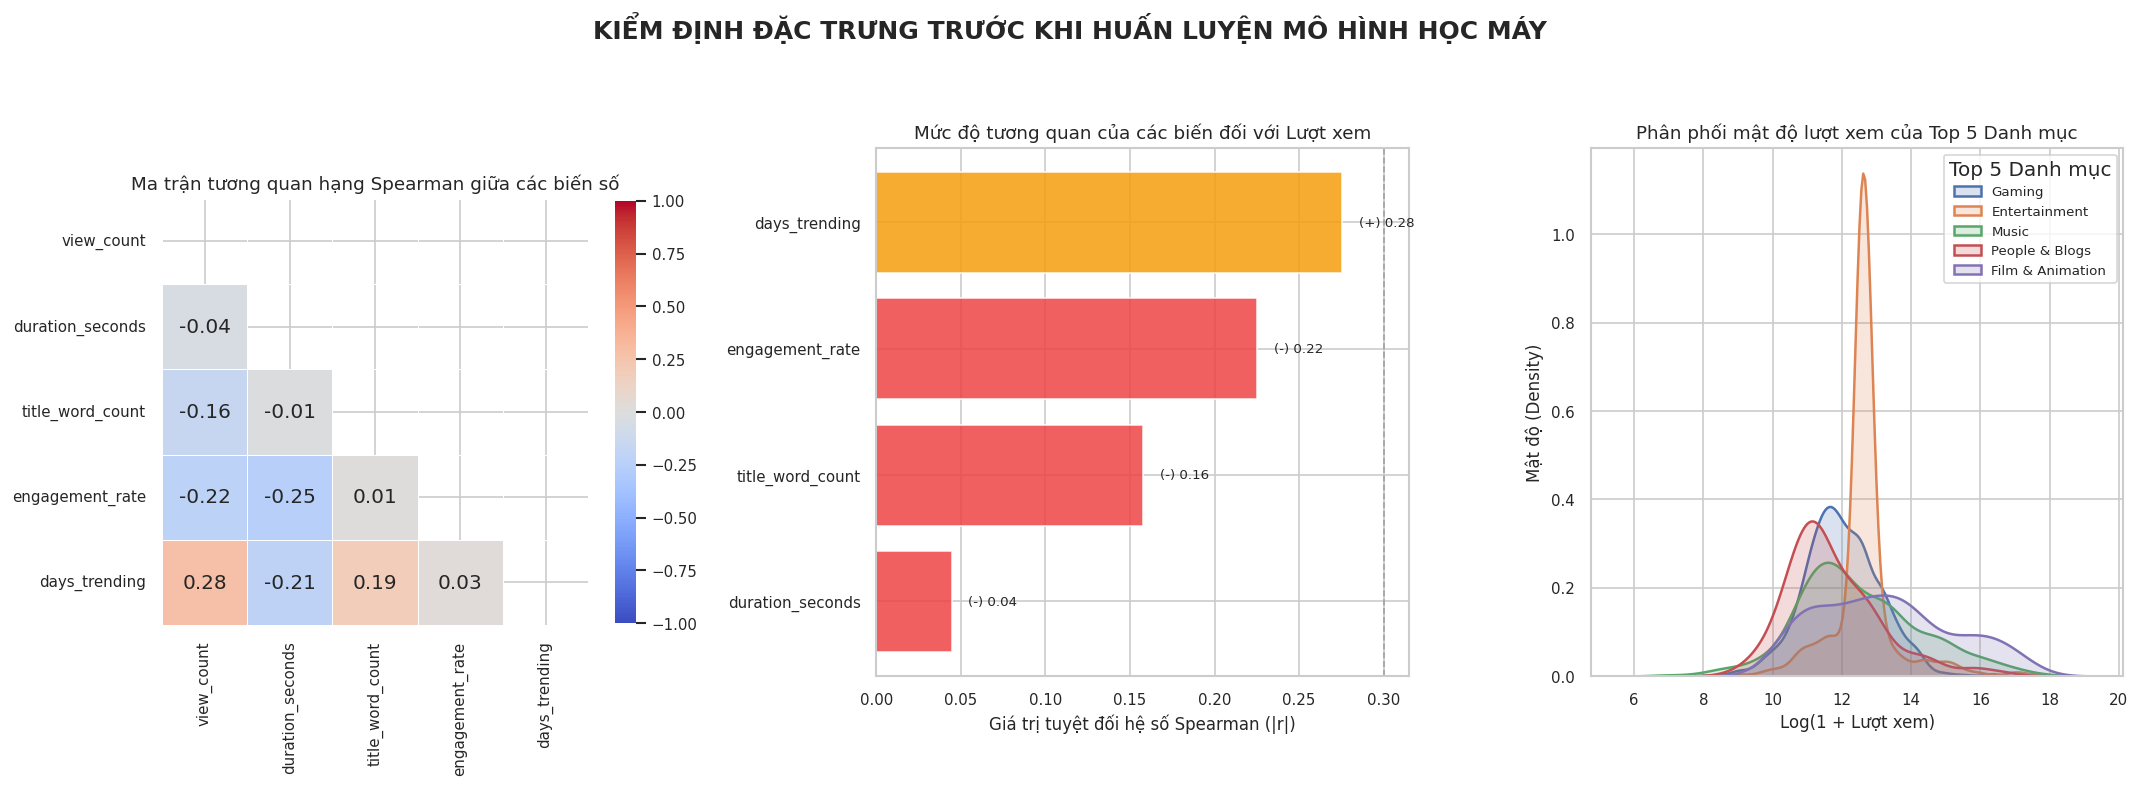

In [6]:
# == BIỂU ĐỒ 5: PHÂN TÍCH CHẨN ĐOÁN & TƯƠNG QUAN ==
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('KIỂM ĐỊNH ĐẶC TRƯNG TRƯỚC KHI HUẤN LUYỆN MÔ HÌNH HỌC MÁY', fontsize=15, fontweight='bold', y=1.05)

num_cols = ['view_count', 'likes', 'comments', 'duration_seconds', 
            'title_word_count', 'engagement_rate', 'days_trending']
num_cols = [c for c in num_cols if c in valid.columns]
corr_matrix = valid[num_cols].corr(method='spearman')

# 5A: Heatmap tương quan
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, ax=axes[0], mask=mask, annot=True, fmt=".2f", 
            cmap='coolwarm', vmin=-1, vmax=1, square=True, linewidths=0.5, cbar_kws={"shrink": .8})
axes[0].set_title('Ma trận tương quan hạng Spearman giữa các biến số')

# 5B: Target-Focused Correlation
target_label = "view_count"
corr_target = corr_matrix[target_label].drop(target_label).abs().sort_values(ascending=True)
corr_sign = corr_matrix[target_label].drop(target_label).reindex(corr_target.index)
colors_bar = [COLOR_ACC if v > 0 else '#EF4444' for v in corr_sign.values]

axes[1].barh(corr_target.index, corr_target.values, color=colors_bar, alpha=0.85)
axes[1].axvline(0.3, color="gray", ls="--", lw=1, alpha=0.6)
axes[1].set_title('Mức độ tương quan của các biến đối với Lượt xem')
axes[1].set_xlabel('Giá trị tuyệt đối hệ số Spearman (|r|)')
for bar, val, sign in zip(axes[1].patches, corr_target.values, corr_sign.values):
    direction = "(+)" if sign > 0 else "(-)"
    axes[1].text(val + 0.01, bar.get_y() + bar.get_height()/2, f"{direction} {val:.2f}", va="center", fontsize=8)

# 5C: Khả năng phân tách (Class Separability)
top_5_cats = valid['category_name'].value_counts().nlargest(5).index
for cat in top_5_cats:
    sns.kdeplot(valid[valid['category_name'] == cat]['log_view_count'], ax=axes[2], label=cat, fill=True, alpha=0.2, linewidth=1.5)
axes[2].set_title('Phân phối mật độ lượt xem của Top 5 Danh mục')
axes[2].set_xlabel('Log(1 + Lượt xem)')
axes[2].set_ylabel('Mật độ (Density)')
axes[2].legend(title='Top 5 Danh mục', fontsize=8)

plt.tight_layout()
plt.show()